In [22]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [23]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('customer_shopping_behavior_analysis.csv')

In [24]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3901,42,Male,Sweater,Accessories,55,South Carolina,M,Yellow,Winter,3.6,No,2-Day Shipping,No,No,39,PayPal,Monthly
1,3902,52,Male,Dress,Outerwear,79,Iowa,S,White,Fall,3.5,No,Express,No,Yes,6,Cash,Monthly
2,3903,44,Female,Sweater,Clothing,57,Wisconsin,M,Brown,Spring,4.5,No,Next Day Air,Yes,Yes,22,Cash,Monthly
3,3904,28,Male,Shoes,Accessories,27,Idaho,S,Olive,Spring,3.5,No,2-Day Shipping,No,No,47,PayPal,Weekly
4,3905,19,Female,Skirt,Clothing,28,New Jersey,M,Olive,Spring,5.0,No,Free Shipping,No,No,13,Venmo,Monthly


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3865 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [27]:
df.describe(include = 'all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3865.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Jacket,Clothing,NaN,Illinois,M,Olive,Winter,NaN,No,Standard,No,No,NaN,Cash,Annually
freq,NaN,NaN,2666,192,1705,NaN,105,1761,178,1028,NaN,2816,680,2244,2217,NaN,683,596
mean,5850.500000,44.403590,NaN,NaN,NaN,59.545128,NaN,NaN,NaN,NaN,3.745071,NaN,NaN,NaN,NaN,24.818974,NaN,NaN
std,1125.977353,15.128811,NaN,NaN,NaN,24.238540,NaN,NaN,NaN,NaN,0.724242,NaN,NaN,NaN,NaN,14.421371,NaN,NaN
min,3901.000000,18.000000,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,4875.750000,31.000000,NaN,NaN,NaN,38.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,12.000000,NaN,NaN
50%,5850.500000,45.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,6825.250000,57.000000,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,37.000000,NaN,NaN


In [28]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             35
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [29]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x : x.fillna(x.median()))

In [30]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [31]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns = {'purchase_amount_(usd)': 'purchase_amount'})
df = df.rename(columns = {'purchase_amount_': 'purchase_amount'})

In [32]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [33]:
## Create a column Age_Group
labels = ['Young Adult', 'Adult', 'Middle-Aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q = 4, labels = labels)

In [34]:
df[['age', 'age_group']].head(10)

,age,age_group
0,42,Adult
1,52,Middle-Aged
2,44,Adult
3,28,Young Adult
4,19,Young Adult
5,33,Adult
6,29,Young Adult
7,37,Adult
8,26,Young Adult
9,62,Senior


In [35]:
## Create a column purchase_frequency_days
frequency_mapping = {'Weekly':7, 'Bi-Weekly':14, 'Monthly':30, 'Quarterly':90, 'Annually':365, 'Every 3 Months':90, 'Fortnightly':14}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [36]:
df[['purchase_frequency_days', 'frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,30,Monthly
1,30,Monthly
2,30,Monthly
3,7,Weekly
4,30,Monthly
5,14,Bi-Weekly
6,14,Bi-Weekly
7,90,Every 3 Months
8,30,Monthly
9,14,Fortnightly


In [37]:
df[['discount_applied', 'promo_code_used']].head(10)

,discount_applied,promo_code_used
0,No,No
1,No,Yes
2,Yes,Yes
3,No,No
4,No,No
5,No,No
6,Yes,No
7,Yes,No
8,No,No
9,No,Yes


In [38]:
(df['discount_applied'] == df['promo_code_used']).all()

False

In [42]:
## Which product categories have the highest average purchase amount?

avg_purchase = df.groupby('category')['purchase_amount'].mean().sort_values(ascending=False)

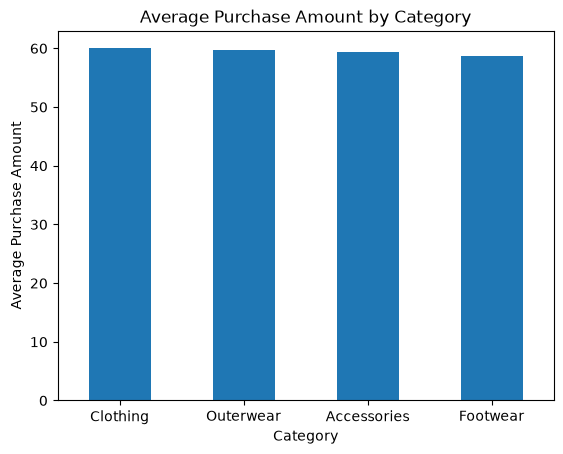

In [43]:
avg_purchase.plot(kind='bar')

plt.title('Average Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Average Purchase Amount')
plt.xticks(rotation=0)
plt.show()

In [45]:
## Which age group has the highest average purchase amount?

avg_purchase_age = df.groupby('age_group')['purchase_amount'].mean().sort_values(ascending=False)

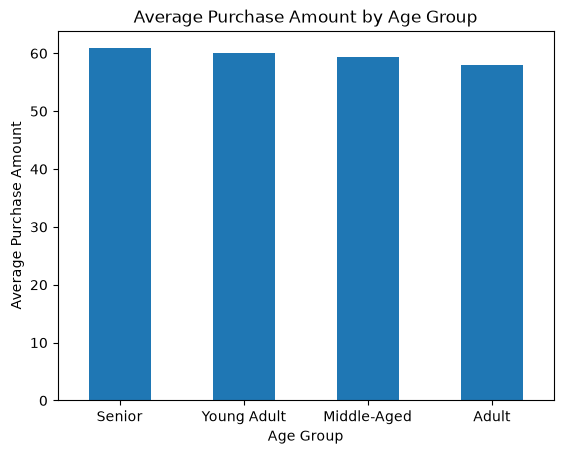

In [46]:
avg_purchase_age.plot(kind='bar')

plt.title('Average Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Amount')
plt.xticks(rotation=0)
plt.show()

In [47]:
## Which gender has the highest average purchase amount?

avg_purchase_gender = df.groupby('gender')['purchase_amount'].mean().sort_values(ascending=False)

gender
Male      59.691298
Female    59.229335
Name: purchase_amount, dtype: float64

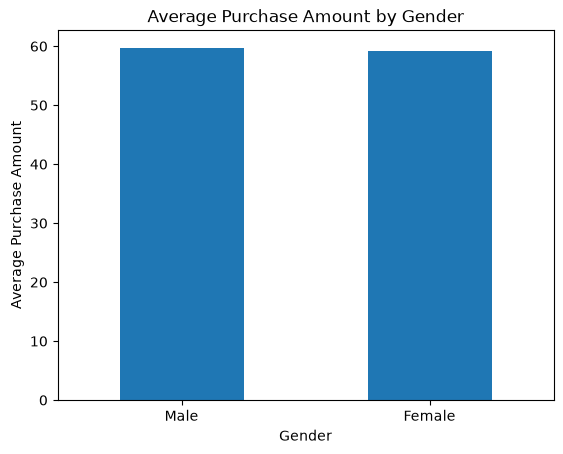

In [48]:
avg_purchase_gender.plot(kind='bar')

plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount')
plt.xticks(rotation=0)
plt.show()

In [50]:
## “Which season has the highest average purchase amount?”

avg_purchase_season = df.groupby('season')['purchase_amount'].mean().sort_values(ascending=False)

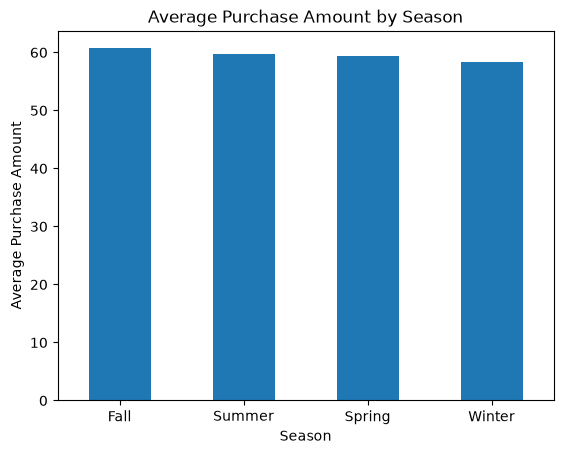

In [51]:
avg_purchase_season.plot(kind='bar')

plt.title('Average Purchase Amount by Season')
plt.xlabel('Season')
plt.ylabel('Average Purchase Amount')
plt.xticks(rotation=0)
plt.show()

In [17]:
pip install mysql-connector-python sqlalchemy

  Using cached mysql_connector_python-26.7.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached sqlalchemy-2.1.1-cp311-cp311-win_amd64.whl.metadata (9.9 kB)
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--

In [2]:
import mysql.connector
from sqlalchemy import create_engine

print("MySQL and SQLAlchemy are working!")

MySQL and SQLAlchemy are working!


In [19]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

username = "root"
password = "My_Password"
host = "localhost"
port = 3306
database = "customer_analysis"

connection_url = URL.create(
    "mysql+mysqlconnector",
    username=username,
    password=password,
    host=host,
    port=port,
    database=database
)

engine = create_engine(connection_url)

print("MySQL engine created successfully!")

MySQL engine created successfully!


In [20]:
with engine.connect() as connection:
    print("MySQL connection successful!")

MySQL connection successful!


In [21]:
table_name = "customer"

df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print("Data successfully loaded into MySQL!")

Data successfully loaded into MySQL!
